In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Load dataset
df = pd.read_csv('fake_or_real_news.csv')

# Convert labels
df['label'] = df['label'].map({'REAL': 1, 'FAKE': 0})

texts = df['text'].astype(str)
labels = df['label'].values

# Tokenization (better vocab size)
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=300)

y = labels

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Improved model (LSTM + Dropout)
model = Sequential([
    Embedding(10000, 128, input_length=300),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=6,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 70s 830ms/step - accuracy: 0.7180 - loss: 0.5625 - val_accuracy: 0.8129 - val_loss: 0.3989
Epoch 2/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 81s 822ms/step - accuracy: 0.9053 - loss: 0.2533 - val_accuracy: 0.8327 - val_loss: 0.3531
Epoch 3/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 64s 805ms/step - accuracy: 0.9615 - loss: 0.1117 - val_accuracy: 0.8595 - val_loss: 0.3840
Epoch 4/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 69s 871ms/step - accuracy: 0.9842 - loss: 0.0478 - val_accuracy: 0.8516 - val_loss: 0.4372
Epoch 5/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 66s 824ms/step - accuracy: 0.9933 - loss: 0.0213 - val_accuracy: 0.8635 - val_loss: 0.4968
Epoch 6/6
80/80 ━━━━━━━━━━━━━━━━━━━━ 64s 805ms/step - accuracy: 0.9988 - loss: 0.0084 - val_accuracy: 0.8919 - val_loss: 0.6232


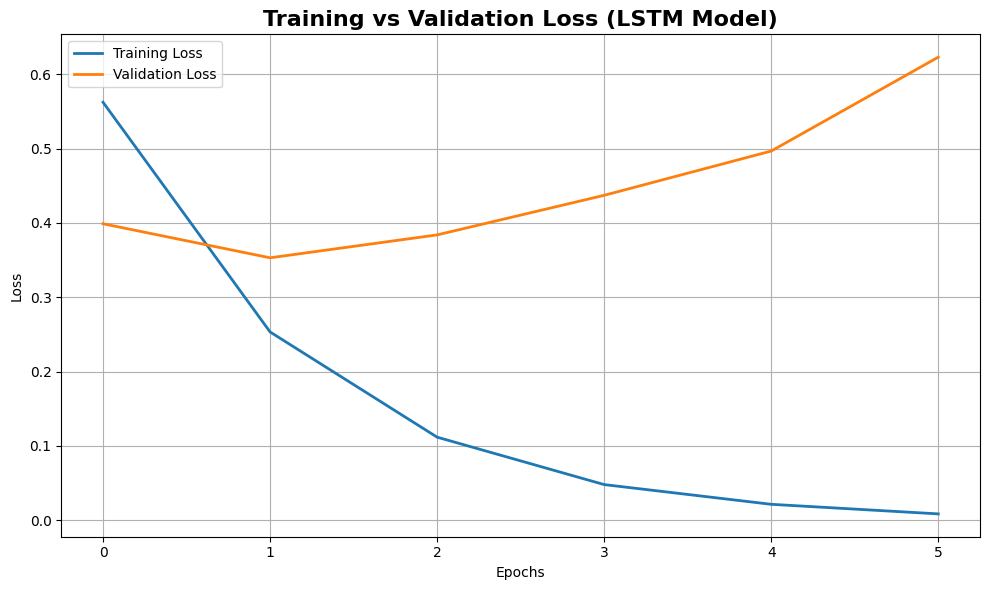

In [3]:
plt.figure(figsize=(10,6))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title("Training vs Validation Loss (LSTM Model)", fontsize=16, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()